# MNIST Pipeline: LeNet-5 Feature Extraction → 10 Logistic Regressors → Softmax

**Pipeline Overview:**
1. Load MNIST dataset
2. Train a LeNet-5 CNN on MNIST
3. Remove the classification head → extract feature vectors
4. Train 10 One-vs-Rest Logistic Regression models (one per digit 0–9)
5. Stack outputs into a 1×10 probability vector → apply Softmax
6. Evaluate with regularization analysis, bias–variance diagnostics, and learning curves

## Cell 1 — Imports

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from Metrics import Metrics
import warnings, os

warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Cell 1b — Logistic Regression (from scratch)

Binary logistic regression with L1/L2 regularization. Used as the classical ML classifier on top of CNN features.

In [17]:
class LogisticRegression:
    """Binary logistic regression with L1/L2 regularization, trained via gradient descent."""

    def __init__(self, lr=0.01, max_iter=2000, C=1.0, tol=1e-6, penalty="l2"):
        self.lr = lr
        self.max_iter = max_iter
        self.C = C              # Inverse regularization strength (smaller → stronger reg)
        self.tol = tol          # Convergence threshold for early stopping
        self.penalty = penalty  # "l1" or "l2"

    @staticmethod
    def _sigmoid(z):
        # Numerically stable sigmoid: split positive/negative to avoid overflow in exp()
        pos = z >= 0
        result = np.empty_like(z, dtype=float)
        result[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
        exp_z = np.exp(z[~pos])
        result[~pos] = exp_z / (1.0 + exp_z)
        return result

    def _add_intercept(self, X):
        # Prepend a column of 1s for the bias term
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        X = self._add_intercept(X)
        n_samples, n_features = X.shape
        self.weights_ = np.zeros(n_features)

        reg = 1.0 / self.C  # Regularization strength λ = 1/C
        prev_loss = np.inf

        for _ in range(self.max_iter):
            z = X @ self.weights_
            h = self._sigmoid(z)
            eps = 1e-15  # Prevent log(0)

            # Binary cross-entropy loss
            loss = (-1 / n_samples) * (
                y @ np.log(h + eps) + (1 - y) @ np.log(1 - h + eps)
            )

            if self.penalty == "l2":
                # L2: adds λ/2 * ||w||² to loss, gradient gets + λ*w
                loss += 0.5 * reg * np.dot(self.weights_, self.weights_)
                grad = (1 / n_samples) * (X.T @ (h - y)) + reg * self.weights_
            elif self.penalty == "l1":
                # L1: adds λ * ||w||₁ to loss, gradient gets + λ*sign(w)
                loss += reg * np.sum(np.abs(self.weights_))
                grad = (1 / n_samples) * (X.T @ (h - y)) + reg * np.sign(self.weights_)

            # Gradient descent step
            self.weights_ -= self.lr * grad

            # Early stopping when loss converges
            if abs(prev_loss - loss) < self.tol:
                break
            prev_loss = loss

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        X = self._add_intercept(X)
        probs_1 = self._sigmoid(X @ self.weights_)
        # Return [P(class=0), P(class=1)] per sample
        return np.column_stack([1 - probs_1, probs_1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

## Cell 2 — Load MNIST & Create 70/15/15 Split

In [18]:
# Preprocessing: pad 28→32 for LeNet-5, normalize with MNIST global stats
transform = transforms.Compose([
    transforms.Pad(2),                          # 28×28 → 32×32 (LeNet-5 input size)
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST global mean / std
])

full_train = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Combine train (60,000) + test (10,000) = 70,000, then re-split 70/15/15
all_indices = np.arange(len(full_train) + len(test_set))
np.random.seed(42)
np.random.shuffle(all_indices)

n_total = len(all_indices)
n_train = int(0.70 * n_total)  # 49,000
n_val   = int(0.15 * n_total)  # 10,500
# n_test = remainder              10,500

train_idx = all_indices[:n_train]
val_idx   = all_indices[n_train:n_train + n_val]
test_idx  = all_indices[n_train + n_val:]

full_dataset = torch.utils.data.ConcatDataset([full_train, test_set])

train_subset = Subset(full_dataset, train_idx)
val_subset   = Subset(full_dataset, val_idx)
test_subset  = Subset(full_dataset, test_idx)

print(f"Split sizes  →  Train: {len(train_subset)}  |  Val: {len(val_subset)}  |  Test: {len(test_subset)}")

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_subset,  batch_size=256, shuffle=False)

Split sizes  →  Train: 49000  |  Val: 10500  |  Test: 10500


## Cell 3 — Define LeNet-5 Architecture

In [19]:
class LeNet5(nn.Module):
    """
    Classic LeNet-5 (LeCun et al., 1998) adapted for MNIST.
    Input : 1 × 32 × 32
    Output: 10-class logits (used only during CNN pretraining)
    """
    def __init__(self):
        super().__init__()
        # ── Convolutional backbone ──
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),     # → 6  × 28 × 28
            nn.ReLU(),
            nn.AvgPool2d(2, 2),                 # → 6  × 14 × 14
            nn.Conv2d(6, 16, kernel_size=5),    # → 16 × 10 × 10
            nn.ReLU(),
            nn.AvgPool2d(2, 2),                 # → 16 ×  5 ×  5
        )
        # ── Fully-connected feature layers ──
        self.feature_fc = nn.Sequential(
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
        )
        # ── Classification head (will be DISABLED later) ──
        self.classifier = nn.Linear(84, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)              # flatten
        x = self.feature_fc(x)
        x = self.classifier(x)
        return x

    def extract_features(self, x):
        """Forward pass through the backbone ONLY → returns 84-d feature vector."""
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.feature_fc(x)
        return x                                # shape: (batch, 84)


model = LeNet5().to(DEVICE)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (feature_fc): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): ReLU()
  )
  (classifier): Linear(in_features=84, out_features=10, bias=True)
)

Total parameters: 61,706


## Cell 4 — Pretrain LeNet-5 on MNIST

In [20]:
EPOCHS   = 10
LR       = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Training ──
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += images.size(0)
    train_losses.append(running_loss / total)
    train_accs.append(correct / total)

    # ── Validation ──
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total   += images.size(0)
    val_losses.append(running_loss / total)
    val_accs.append(correct / total)

    print(f"Epoch {epoch:>2}/{EPOCHS}  │  "
          f"Train Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.4f}  │  "
          f"Val   Loss: {val_losses[-1]:.4f}  Acc: {val_accs[-1]:.4f}")

print("\n✓ LeNet-5 pretraining complete.")

Epoch  1/10  │  Train Loss: 0.4705  Acc: 0.8584  │  Val   Loss: 0.1884  Acc: 0.9415
Epoch  2/10  │  Train Loss: 0.1234  Acc: 0.9619  │  Val   Loss: 0.0928  Acc: 0.9719
Epoch  3/10  │  Train Loss: 0.0790  Acc: 0.9757  │  Val   Loss: 0.0690  Acc: 0.9787
Epoch  4/10  │  Train Loss: 0.0605  Acc: 0.9811  │  Val   Loss: 0.0625  Acc: 0.9823
Epoch  5/10  │  Train Loss: 0.0529  Acc: 0.9828  │  Val   Loss: 0.0650  Acc: 0.9806
Epoch  6/10  │  Train Loss: 0.0441  Acc: 0.9859  │  Val   Loss: 0.0612  Acc: 0.9811
Epoch  7/10  │  Train Loss: 0.0382  Acc: 0.9878  │  Val   Loss: 0.0508  Acc: 0.9851
Epoch  8/10  │  Train Loss: 0.0347  Acc: 0.9888  │  Val   Loss: 0.0522  Acc: 0.9850
Epoch  9/10  │  Train Loss: 0.0300  Acc: 0.9905  │  Val   Loss: 0.0497  Acc: 0.9855
Epoch 10/10  │  Train Loss: 0.0265  Acc: 0.9914  │  Val   Loss: 0.0515  Acc: 0.9845

✓ LeNet-5 pretraining complete.


## Cell 5 — Plot CNN Training Curves

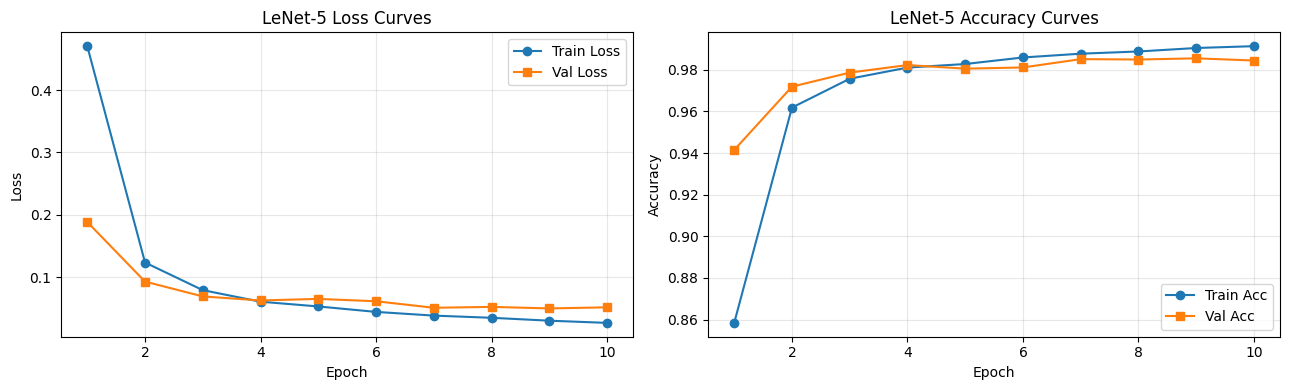

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, train_losses, "o-", label="Train Loss")
ax1.plot(epochs_range, val_losses,   "s-", label="Val Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("LeNet-5 Loss Curves")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_accs, "o-", label="Train Acc")
ax2.plot(epochs_range, val_accs,   "s-", label="Val Acc")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("LeNet-5 Accuracy Curves")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/lenet5_training_curves.png", dpi=150)
plt.show()

## Cell 6 — Disable Classification Head & Extract Features

Freeze the entire network — we only need it as a feature extractor now.  
The classifier head is effectively **DISABLED**: we call `extract_features()` instead of `forward()`, so the final `Linear(84→10)` layer is never executed.

In [22]:
# Freeze the CNN — we only need it as a fixed feature extractor from here on
model.eval()
for param in model.parameters():
    param.requires_grad = False

def extract_all_features(loader):
    """Run every batch through LeNet-5 backbone (no classifier head) and collect 84-d feature vectors."""
    all_feats, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            feats  = model.extract_features(images)  # bypasses classifier → 84-d vector per image
            all_feats.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_feats), np.concatenate(all_labels)

# Convert all images to feature vectors for the classical ML stage
X_train, y_train = extract_all_features(train_loader)
X_val,   y_val   = extract_all_features(val_loader)
X_test,  y_test  = extract_all_features(test_loader)

print(f"Feature shapes  →  Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
print(f"Feature vector dimensionality: {X_train.shape[1]}  (classifier head disabled)")

Feature shapes  →  Train: (49000, 84)  |  Val: (10500, 84)  |  Test: (10500, 84)
Feature vector dimensionality: 84  (classifier head disabled)


## Cell 7 — Train 10 One-vs-Rest Logistic Regression Models

Each model k ∈ {0, 1, …, 9} is a **binary** logistic regression:
- Positive class: digit == k
- Negative class: digit != k

After training, each model outputs P(digit == k | features).  
We stack these 10 probabilities and apply softmax.

In [23]:
N_CLASSES = 10
lr_models = {}

print("Training 10 binary Logistic Regression models (One-vs-Rest):\n")

for k in range(N_CLASSES):

    # One-vs-Rest: digit k = positive class (1), all others = negative class (0)
    y_bin_train = (y_train == k).astype(int)
    y_bin_val   = (y_val == k).astype(int)

    clf = LogisticRegression(
        penalty="l2",
        C=1.0,
        lr=0.01,
        max_iter=2000,
    )

    clf.fit(X_train, y_bin_train)

    acc_train = Metrics.accuracy_score(y_bin_train, clf.predict(X_train))
    acc_val   = Metrics.accuracy_score(y_bin_val, clf.predict(X_val))

    print(f"  Digit {k}  │  Train Acc: {acc_train:.4f}  │  Val Acc: {acc_val:.4f}")

    lr_models[k] = clf

print("\n✓ All 10 logistic regression models trained.")

Training 10 binary Logistic Regression models (One-vs-Rest):

  Digit 0  │  Train Acc: 0.9972  │  Val Acc: 0.9967
  Digit 1  │  Train Acc: 0.9972  │  Val Acc: 0.9973
  Digit 2  │  Train Acc: 0.9951  │  Val Acc: 0.9950
  Digit 3  │  Train Acc: 0.9962  │  Val Acc: 0.9958
  Digit 4  │  Train Acc: 0.9954  │  Val Acc: 0.9943
  Digit 5  │  Train Acc: 0.9949  │  Val Acc: 0.9930
  Digit 6  │  Train Acc: 0.9981  │  Val Acc: 0.9972
  Digit 7  │  Train Acc: 0.9957  │  Val Acc: 0.9950
  Digit 8  │  Train Acc: 0.9933  │  Val Acc: 0.9916
  Digit 9  │  Train Acc: 0.9933  │  Val Acc: 0.9922

✓ All 10 logistic regression models trained.


## Cell 8 — Build the 1×10 Probability Vector & Apply Softmax

In [24]:
def predict_pipeline(X, lr_models):
    """Collect P(digit=k) from each of the 10 binary LR models, then apply softmax.

    Returns:
        probs      : (N, 10) softmax probabilities
        predictions: (N,)    argmax class labels
    """
    raw_probs = np.zeros((X.shape[0], N_CLASSES))
    for k in range(N_CLASSES):
        # Each LR model outputs [P(not-k), P(k)] — we take P(k)
        raw_probs[:, k] = lr_models[k].predict_proba(X)[:, 1]

    # Softmax: subtract row-max for numerical stability, then normalize
    exp_scores = np.exp(raw_probs - raw_probs.max(axis=1, keepdims=True))
    probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)

    predictions = probs.argmax(axis=1)
    return probs, predictions

# Run full pipeline on each split
_, y_pred_train = predict_pipeline(X_train, lr_models)
_, y_pred_val   = predict_pipeline(X_val,   lr_models)
probs_test, y_pred_test = predict_pipeline(X_test, lr_models)

print("═" * 60)
print("        FULL PIPELINE RESULTS  (LeNet-5 → 10×LR → Softmax)")
print("═" * 60)
print(f"  Train Accuracy : {Metrics.accuracy_score(y_train, y_pred_train):.4f}")
print(f"  Val   Accuracy : {Metrics.accuracy_score(y_val,   y_pred_val):.4f}")
print(f"  Test  Accuracy : {Metrics.accuracy_score(y_test,  y_pred_test):.4f}")
print("═" * 60)

════════════════════════════════════════════════════════════
        FULL PIPELINE RESULTS  (LeNet-5 → 10×LR → Softmax)
════════════════════════════════════════════════════════════
  Train Accuracy : 0.9903
  Val   Accuracy : 0.9843
  Test  Accuracy : 0.9850
════════════════════════════════════════════════════════════


## Cell 9 — Detailed Test-Set Evaluation


Classification Report (Test Set):


   precision     recall   f1-score    support

0     0.9951     0.9931     0.9941       1018
1     0.9820     0.9860     0.9840       1216
2     0.9798     0.9789     0.9793       1088
3     0.9810     0.9895     0.9852       1045
4     0.9882     0.9863     0.9872       1019
5     0.9905     0.9801     0.9853        956
6     0.9866     0.9961     0.9913       1031
7     0.9825     0.9843     0.9834       1082
8     0.9799     0.9789     0.9794       1044
9     0.9869     0.9770     0.9819       1001

accuracy                           0.9850      10500
macro avg     0.9852     0.9850     0.9851      10500
weighted avg     0.9851     0.9850     0.9850      10500




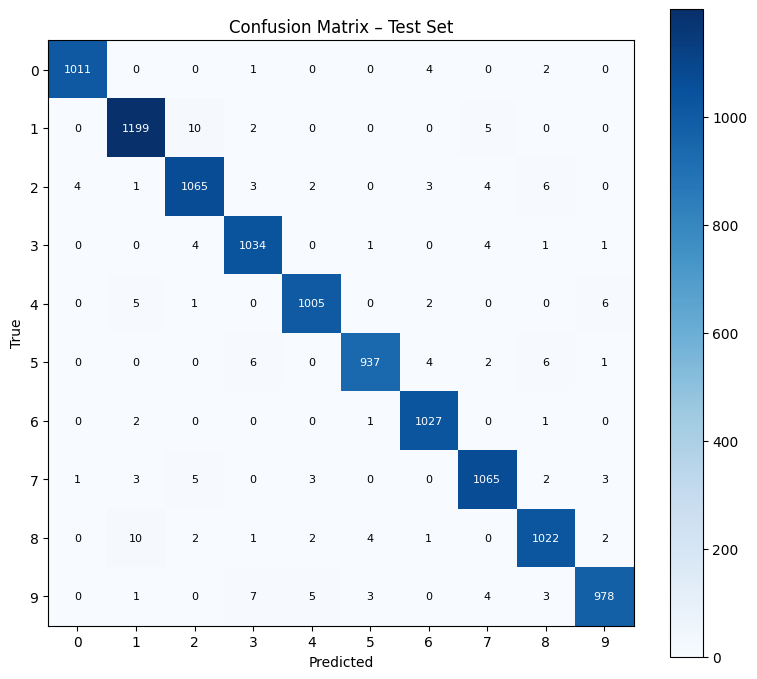

In [25]:
print("\nClassification Report (Test Set):\n")
print(Metrics.classification_report(y_test, y_pred_test, digits=4))

# Confusion matrix
cm = Metrics.confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix – Test Set")
for i in range(10):
    for j in range(10):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8, color=color)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150)
plt.show()

## Cell 10 — Sample Predictions Visualization

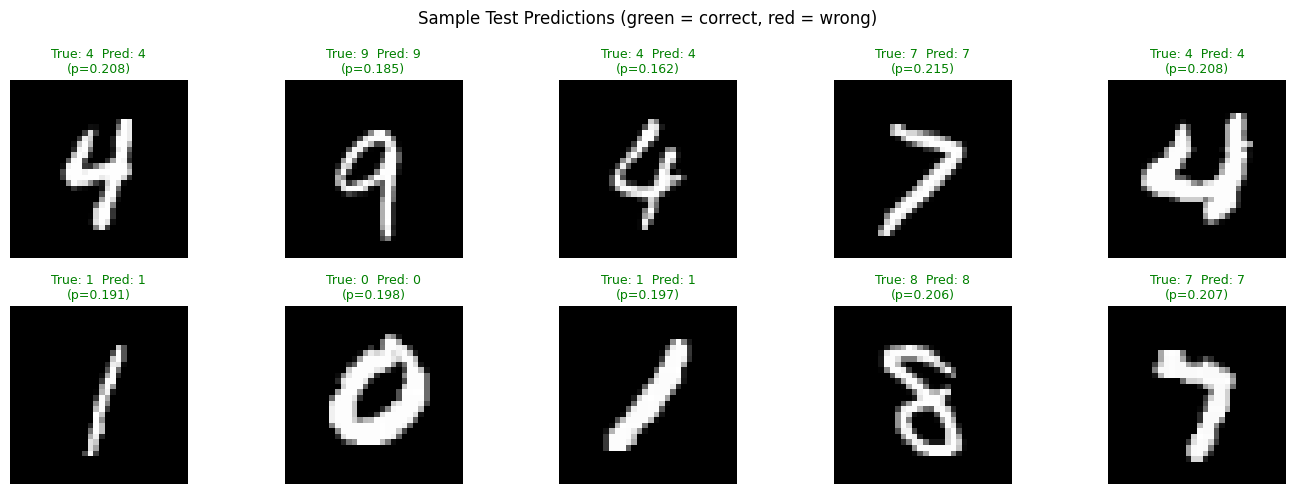

In [26]:
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
sample_indices = np.random.choice(len(X_test), 10, replace=False)

for ax, idx in zip(axes.ravel(), sample_indices):
    # Retrieve the original image from the test subset
    img, true_label = test_subset[idx]
    img_np = img.squeeze().numpy()

    pred_label = y_pred_test[idx]
    prob       = probs_test[idx, pred_label]
    color      = "green" if pred_label == true_label else "red"

    ax.imshow(img_np, cmap="gray")
    ax.set_title(f"True: {true_label}  Pred: {pred_label}\n(p={prob:.3f})", fontsize=9, color=color)
    ax.axis("off")

plt.suptitle("Sample Test Predictions (green = correct, red = wrong)", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/sample_predictions.png", dpi=150)
plt.show()

---
# Regularization & Diagnostics

## Cell 11 — L1 vs L2 Regularization Sweep

`C = 1 / λ` (smaller C → stronger regularization).  
We sweep C for both L1 and L2 and plot train vs validation accuracy.

Regularization sweep (this may take a few minutes)...

  L1  C=0.001     │  Train: 0.1484  Val: 0.1502
  L1  C=0.01      │  Train: 0.1599  Val: 0.1595
  L1  C=0.1       │  Train: 0.1793  Val: 0.1698
  L1  C=1.0       │  Train: 0.5633  Val: 0.5667
  L1  C=10.0      │  Train: 0.9874  Val: 0.9817

  L2  C=0.001     │  Train: 0.0992  Val: 0.0974
  L2  C=0.01      │  Train: 0.9359  Val: 0.9331
  L2  C=0.1       │  Train: 0.9872  Val: 0.9822
  L2  C=1.0       │  Train: 0.9903  Val: 0.9843
  L2  C=10.0      │  Train: 0.9917  Val: 0.9867



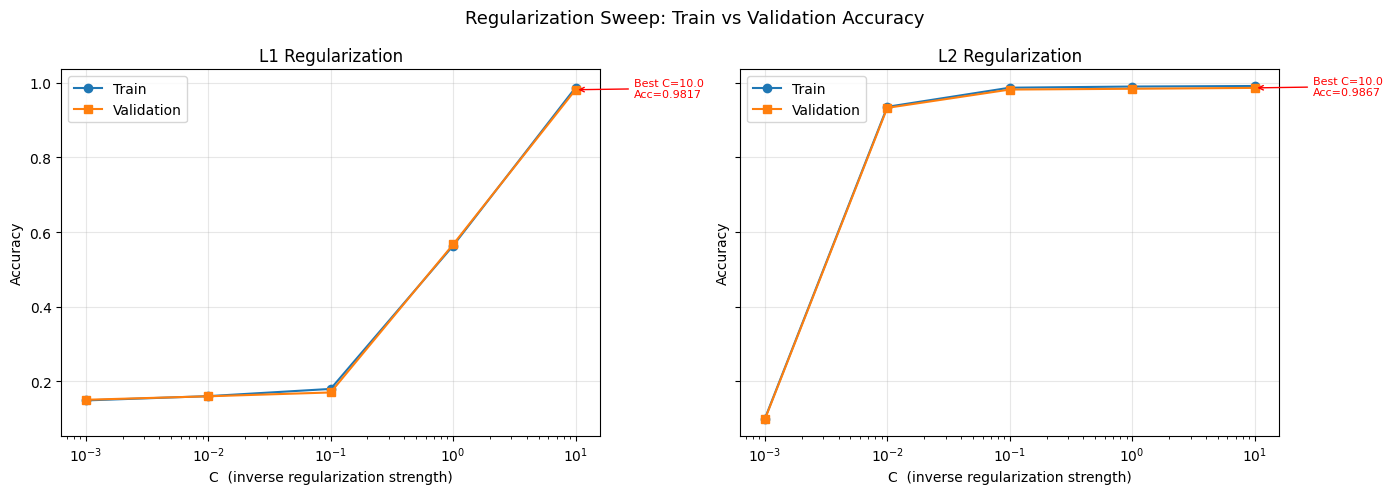

In [27]:
# Sweep across multiple C values to find the best regularization strength
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]

results = {
    "l1": {"train": [], "val": []},
    "l2": {"train": [], "val": []}
}

print("Regularization sweep (this may take a few minutes)...\n")

for penalty_type in ["l1", "l2"]:

    for C in C_values:

        temp_models = {}

        for k in range(N_CLASSES):

            clf = LogisticRegression(
                penalty=penalty_type,
                C=C,
                lr=0.01,
                max_iter=3000,
            )

            clf.fit(X_train, (y_train == k).astype(int))

            temp_models[k] = clf

        _, preds_tr = predict_pipeline(X_train, temp_models)
        _, preds_val = predict_pipeline(X_val, temp_models)

        acc_tr = Metrics.accuracy_score(y_train, preds_tr)
        acc_val = Metrics.accuracy_score(y_val, preds_val)

        results[penalty_type]["train"].append(acc_tr)
        results[penalty_type]["val"].append(acc_val)

        print(
            f"  {penalty_type.upper()}  C={C:<8}  │  "
            f"Train: {acc_tr:.4f}  Val: {acc_val:.4f}"
        )

    print()

# Plot train vs validation accuracy for each C value
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 5), sharey=True
)

for ax, pen in zip([ax1, ax2], ["l1", "l2"]):

    ax.plot(C_values, results[pen]["train"], "o-", label="Train")
    ax.plot(C_values, results[pen]["val"], "s-", label="Validation")

    ax.set_xscale("log")
    ax.set_xlabel("C  (inverse regularization strength)")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{pen.upper()} Regularization")

    ax.legend()
    ax.grid(True, alpha=0.3)

    # Annotate best validation point
    best_idx = np.argmax(results[pen]["val"])
    best_c = C_values[best_idx]
    best_acc = results[pen]["val"][best_idx]

    ax.annotate(
        f"Best C={best_c}\nAcc={best_acc:.4f}",
        xy=(best_c, best_acc),
        fontsize=8,
        arrowprops=dict(arrowstyle="->", color="red"),
        xytext=(best_c * 3, best_acc - 0.02),
        color="red"
    )

plt.suptitle(
    "Regularization Sweep: Train vs Validation Accuracy",
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    "outputs/regularization_sweep.png",
    dpi=150
)

plt.show()

## Cell 12 — Bias–Variance / Overfitting–Underfitting Diagnosis

In [28]:
print("=" * 65)
print("   BIAS–VARIANCE & OVERFITTING / UNDERFITTING DIAGNOSIS")
print("=" * 65)

# Using the best L2 C from the sweep
best_l2_idx = np.argmax(results["l2"]["val"])
best_C = C_values[best_l2_idx]

# Recompute with different regularization strengths
diag_Cs = {
    "Very Strong Reg (C=0.001)": 0.001,
    "Strong Reg (C=0.01)": 0.01,
    "Moderate Reg (C=0.1)": 0.1,
    f"Optimal (C={best_C})": best_C,
    "Weak Reg (C=10)": 10.0,
    "No Reg (C=100)": 100.0
}

print(f"\n{'Setting':<30} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>8}  Diagnosis")
print("-" * 85)

for label, C in diag_Cs.items():

    temp_models = {}

    for k in range(N_CLASSES):

        clf = LogisticRegression(
            penalty="l2",
            C=C,
            lr=0.01,
            max_iter=3000,
        )

        clf.fit(X_train, (y_train == k).astype(int))

        temp_models[k] = clf

    _, p_tr = predict_pipeline(X_train, temp_models)
    _, p_val = predict_pipeline(X_val, temp_models)

    acc_tr = Metrics.accuracy_score(y_train, p_tr)
    acc_val = Metrics.accuracy_score(y_val, p_val)

    gap = acc_tr - acc_val

    # Diagnosis heuristic
    if acc_tr < 0.95 and acc_val < 0.95:
        diagnosis = "⚠ UNDERFITTING (high bias)"

    elif gap > 0.03:
        diagnosis = "⚠ OVERFITTING (high variance)"

    elif gap > 0.015:
        diagnosis = "~ Slight overfit"

    else:
        diagnosis = "✓ Good fit"

    print(
        f"  {label:<28} "
        f"{acc_tr:>10.4f} "
        f"{acc_val:>10.4f} "
        f"{gap:>+8.4f}  "
        f"{diagnosis}"
    )

print("-" * 85)

print("""
Interpretation Guide:
  • High bias (underfitting)
      → both train & validation accuracy are low
      → model is too simple or regularization too strong

  • High variance (overfitting)
      → train accuracy much higher than validation accuracy
      → model memorizes training data

  • Good fit
      → both accuracies are high
      → train/validation gap is small (< ~1.5%)
""")

   BIAS–VARIANCE & OVERFITTING / UNDERFITTING DIAGNOSIS

Setting                         Train Acc    Val Acc      Gap  Diagnosis
-------------------------------------------------------------------------------------
  Very Strong Reg (C=0.001)        0.0992     0.0974  +0.0018  ⚠ UNDERFITTING (high bias)
  Strong Reg (C=0.01)              0.9359     0.9331  +0.0028  ⚠ UNDERFITTING (high bias)
  Moderate Reg (C=0.1)             0.9872     0.9822  +0.0050  ✓ Good fit
  Optimal (C=10.0)                 0.9917     0.9867  +0.0050  ✓ Good fit
  Weak Reg (C=10)                  0.9917     0.9867  +0.0050  ✓ Good fit
  No Reg (C=100)                   0.9930     0.9878  +0.0052  ✓ Good fit
-------------------------------------------------------------------------------------

Interpretation Guide:
  • High bias (underfitting)
      → both train & validation accuracy are low
      → model is too simple or regularization too strong

  • High variance (overfitting)
      → train accuracy much hig

## Cell 13 — Learning Curves

We plot train & validation accuracy as a function of training-set size to visualise bias–variance behaviour.

Computing learning curves (this will take a few minutes)...



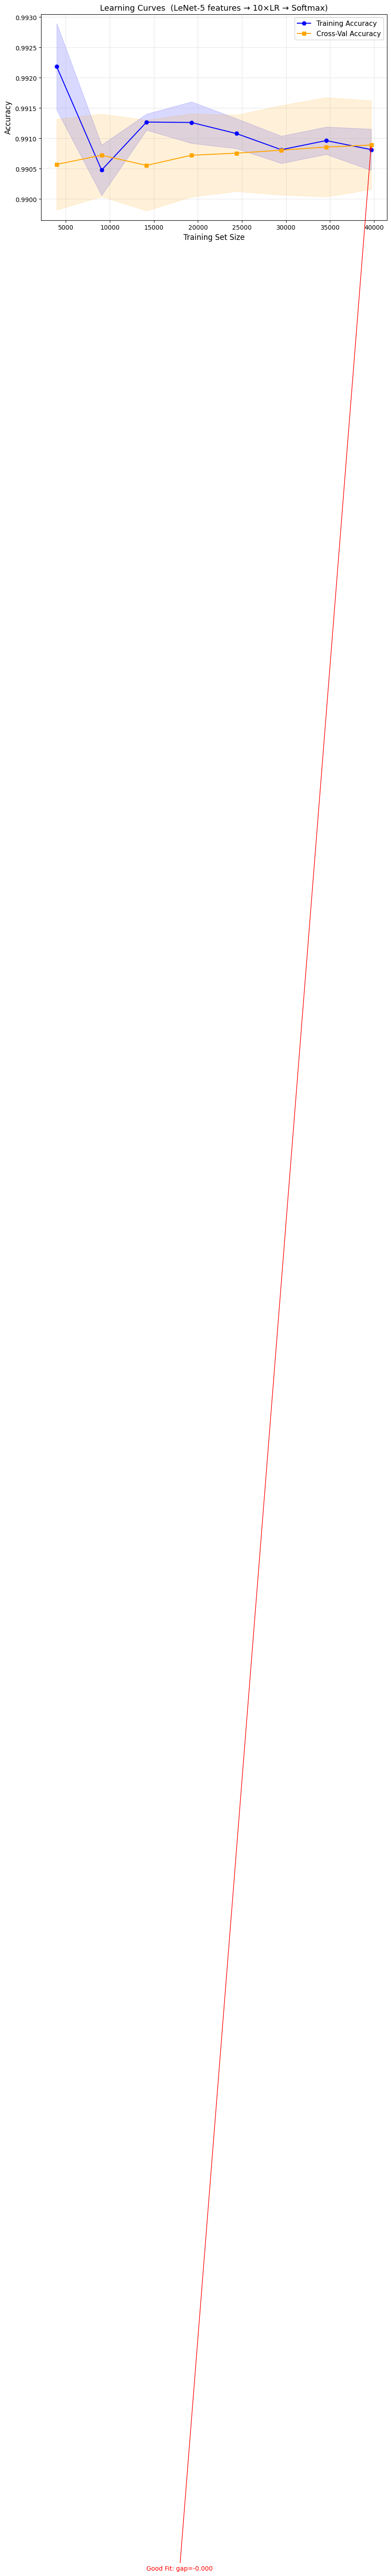

In [29]:
class OvRSoftmaxClassifier:
    """Wraps the 10-LR + softmax pipeline into a single estimator for Metrics.learning_curve()."""

    def __init__(self, C=1.0, penalty="l2"):
        self.C = C
        self.penalty = penalty

    def fit(self, X, y):
        self.models_ = {}
        for k in range(10):
            clf = LogisticRegression(
                penalty=self.penalty,
                C=self.C,
                lr=0.01,
                max_iter=3000,
            )
            clf.fit(X, (y == k).astype(int))
            self.models_[k] = clf
        return self

    def predict(self, X):
        raw = np.zeros((X.shape[0], 10))
        for k in range(10):
            raw[:, k] = self.models_[k].predict_proba(X)[:, 1]
        # Softmax normalization
        exp_s = np.exp(raw - raw.max(axis=1, keepdims=True))
        probs = exp_s / exp_s.sum(axis=1, keepdims=True)
        return probs.argmax(axis=1)


# Combine train + validation for learning curve analysis (more data for CV folds)
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

print("Computing learning curves (this will take a few minutes)...\n")

# Train on increasing fractions of data and evaluate via 3-fold cross-validation
train_sizes_abs, train_scores, val_scores = Metrics.learning_curve(
    estimator=OvRSoftmaxClassifier(C=best_C, penalty="l2"),
    X=X_trainval,
    y=y_trainval,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

# Shaded region = ±1 std across CV folds
ax.fill_between(
    train_sizes_abs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color="blue"
)

ax.fill_between(
    train_sizes_abs,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15,
    color="orange"
)

ax.plot(
    train_sizes_abs,
    train_mean,
    "o-",
    color="blue",
    label="Training Accuracy"
)

ax.plot(
    train_sizes_abs,
    val_mean,
    "s-",
    color="orange",
    label="Cross-Val Accuracy"
)

ax.set_xlabel("Training Set Size", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)

ax.set_title(
    "Learning Curves  (LeNet-5 features → 10×LR → Softmax)",
    fontsize=13
)

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate bias/variance diagnosis based on final gap
final_gap = train_mean[-1] - val_mean[-1]

if final_gap > 0.03:

    diagnosis_text = (
        "High Variance: gap={:.3f}\n"
        "Consider more data or stronger regularisation"
    ).format(final_gap)

elif train_mean[-1] < 0.95:

    diagnosis_text = (
        "High Bias: train acc={:.3f}\n"
        "Consider richer features or less regularisation"
    ).format(train_mean[-1])

else:

    diagnosis_text = "Good Fit: gap={:.3f}".format(final_gap)

ax.annotate(
    diagnosis_text,
    xy=(train_sizes_abs[-1], val_mean[-1]),
    xytext=(train_sizes_abs[2], val_mean[-1] - 0.04),
    fontsize=10,
    color="red",
    arrowprops=dict(arrowstyle="->", color="red")
)

plt.tight_layout()

plt.savefig(
    "outputs/learning_curves.png",
    dpi=150
)

plt.show()

## Cell 14 — Final Summary

In [30]:
print("\n" + "═" * 65)
print("                       PIPELINE SUMMARY")
print("═" * 65)
print(f"""
  1. Data        : MNIST (70,000 images) split 70/15/15
  2. CNN         : LeNet-5 pretrained ({EPOCHS} epochs, Adam lr={LR})
                   Classification head DISABLED → 84-d feature vectors
  3. Classifiers : 10 binary Logistic Regression (One-vs-Rest)
                   Best L2 regularization: C = {best_C}
  4. Output      : 10-element probability vector → Softmax → argmax

  Final Test Accuracy : {Metrics.accuracy_score(y_test, y_pred_test):.4f}

  Diagnostics         : Regularization sweep (L1 & L2)
                        Bias–variance table
                        Learning curves

  Plots saved to      : outputs/
""")
print("═" * 65)


═════════════════════════════════════════════════════════════════
                       PIPELINE SUMMARY
═════════════════════════════════════════════════════════════════

  1. Data        : MNIST (70,000 images) split 70/15/15
  2. CNN         : LeNet-5 pretrained (10 epochs, Adam lr=0.001)
                   Classification head DISABLED → 84-d feature vectors
  3. Classifiers : 10 binary Logistic Regression (One-vs-Rest)
                   Best L2 regularization: C = 10.0
  4. Output      : 10-element probability vector → Softmax → argmax

  Final Test Accuracy : 0.9850

  Diagnostics         : Regularization sweep (L1 & L2)
                        Bias–variance table
                        Learning curves

  Plots saved to      : outputs/

═════════════════════════════════════════════════════════════════


In [31]:
import pickle

torch.save(model.state_dict(), "lenet5_mnist.pth")

with open("lr_models.pkl", "wb") as f:
    pickle.dump(lr_models, f)

print("Saved lenet5_mnist.pth and lr_models.pkl")

Saved lenet5_mnist.pth and lr_models.pkl
